In [5]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
!pip install seaborn adjustText

In [7]:
import seaborn as sns
from adjustText import adjust_text

In [12]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

In [13]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by = 'median', ascending = False)
df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by = 'count', ascending = False)
df_DA_skills = df_DA_skills.head(10).sort_values(by = 'median', ascending = False)

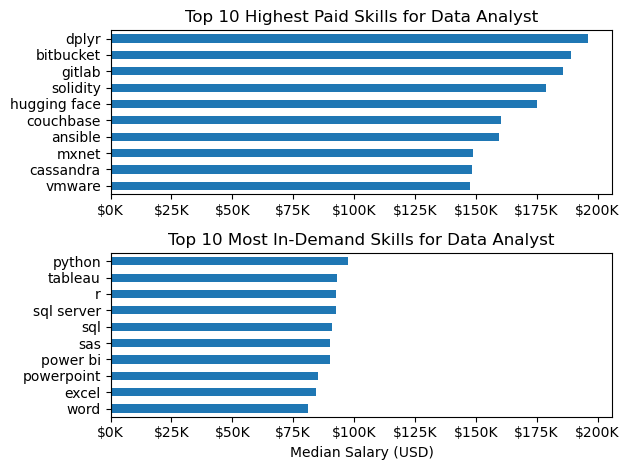

In [14]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay[::-1].plot(kind = 'barh', y = 'median', ax = ax[0], legend = False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

df_DA_skills[::-1].plot(kind = 'barh', y = 'median', ax = ax[1], legend = False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

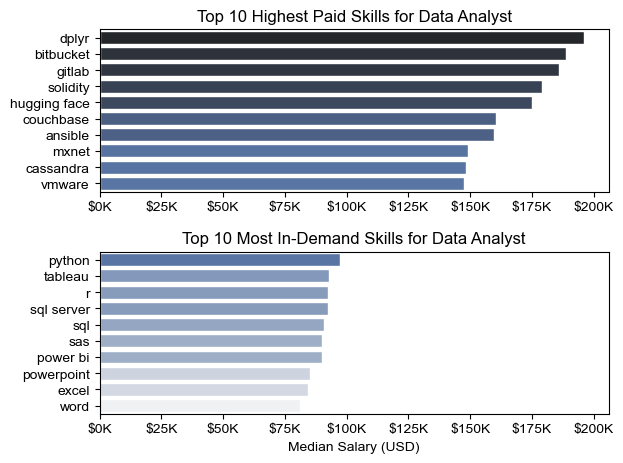

In [23]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style = 'ticks')

sns.barplot(data = df_DA_top_pay, x = 'median', y = df_DA_top_pay.index, ax = ax[0], hue = 'median', palette = 'dark:b_r')
ax[0].legend().remove()
#df_DA_top_pay[::-1].plot(kind = 'barh', y = 'median', ax = ax[0], legend = False)

ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

sns.barplot(data = df_DA_skills, x = 'median', y = df_DA_skills.index, ax = ax[1], hue = 'median', palette = 'light:b')
ax[1].legend().remove()
#df_DA_skills[::-1].plot(kind = 'barh', y = 'median', ax = ax[1], legend = False)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

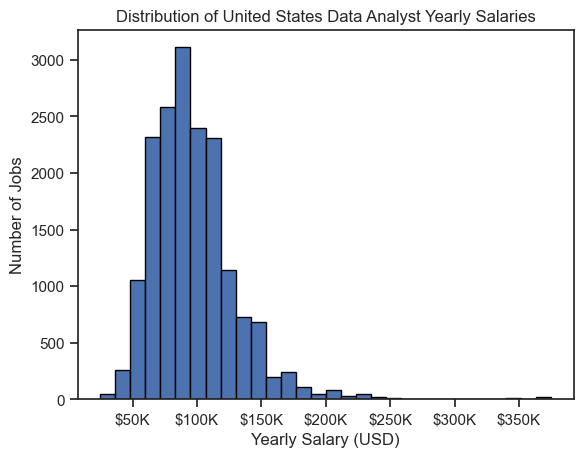

In [25]:
df_DA_US['salary_year_avg'].plot(kind = 'hist', bins = 30, edgecolor = 'black')

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

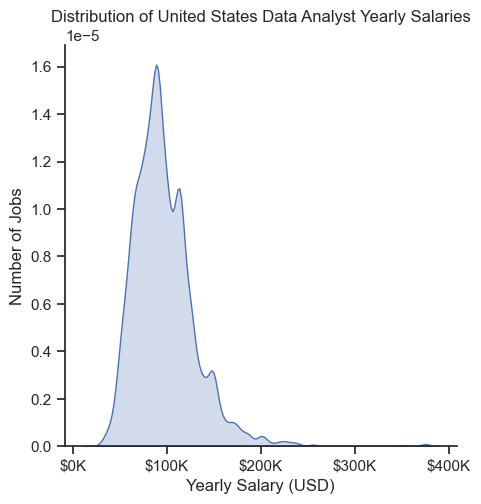

In [37]:
sns.set_theme(style = 'ticks')
sns.displot(df_DA_US['salary_year_avg'], kind = 'kde', fill = True, common_norm = False)
#df_DA_US['salary_year_avg'].plot(kind = 'hist', bins = 30, edgecolor = 'black')

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

C:\Users\yhk25\AppData\Local\Temp\ipykernel_6392\229291651.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels = job_titles, vert = False)


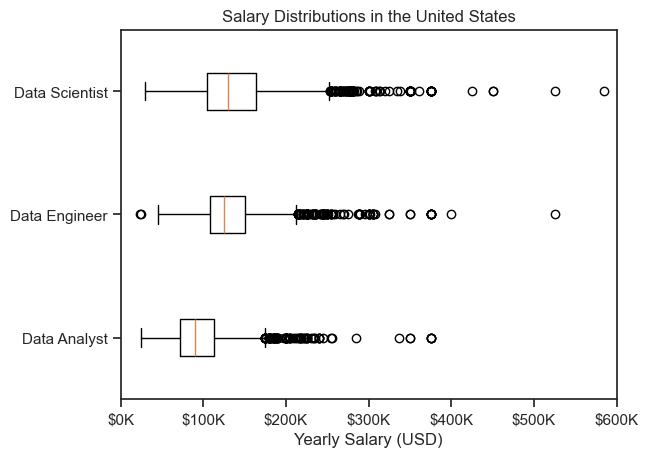

In [31]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset = ['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels = job_titles, vert = False)
plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()


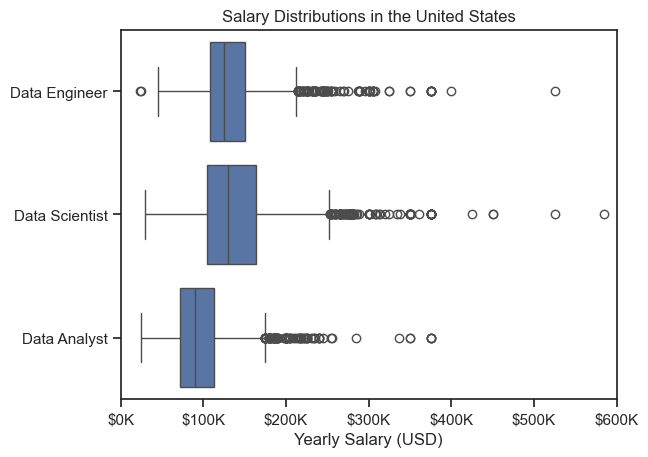

In [35]:
sns.boxplot(data = df_US, x = 'salary_year_avg', y = 'job_title_short')
#plt.boxplot(job_list, labels = job_titles, vert = False)

plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()


## Problem

In [ ]:
top_companies = df['company_name'].value_counts().head(10)

top_companies = top_companies.reset_index()

,company_name,count
0,Emprego,6664
1,Booz Allen Hamilton,2879
2,Dice,2827
3,Harnham,2547
4,Insight Global,2254
5,Citi,2164
6,Confidenziale,2040
7,Listopro,1984
8,Capital One,1946
9,Walmart,1863


In [40]:
top_companies.columns = ['company', 'count']

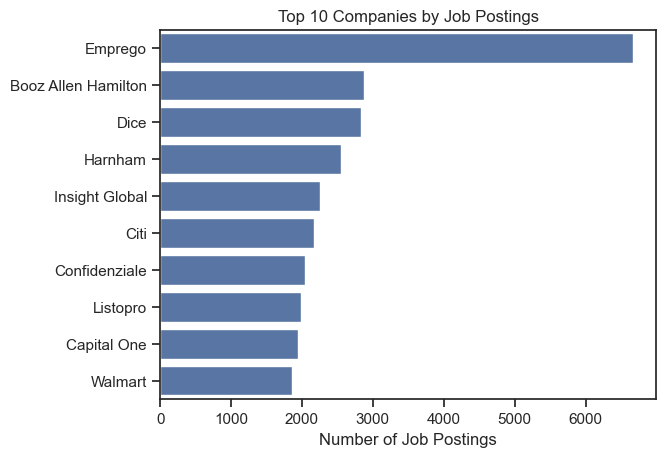

In [42]:
sns.barplot(data = top_companies, x = 'count', y = 'company')

sns.set_theme(style = 'ticks')
plt.title('Top 10 Companies by Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()

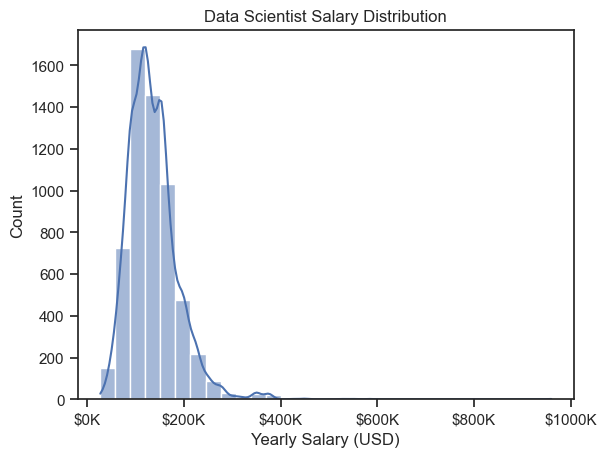

In [43]:
df_DS = df[df['job_title_short'] == 'Data Scientist'].copy()
df_DS = df_DS.dropna(subset = ['salary_year_avg'])

sns.histplot(data = df_DS, x = 'salary_year_avg', bins = 30, kde = True)

plt.title('Data Scientist Salary Distribution')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Count')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()

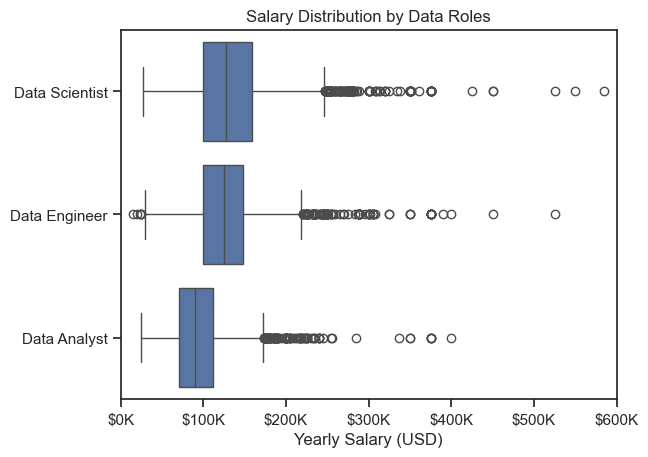

In [44]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_roles = df[df['job_title_short'].isin(job_titles)].copy()
df_roles = df_roles.dropna(subset = ['salary_year_avg'])

sns.boxplot(data=df_roles, x='salary_year_avg', y='job_title_short')

sns.set_theme(style = 'ticks')
plt.title('Salary Distribution by Data Roles')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

plt.show()

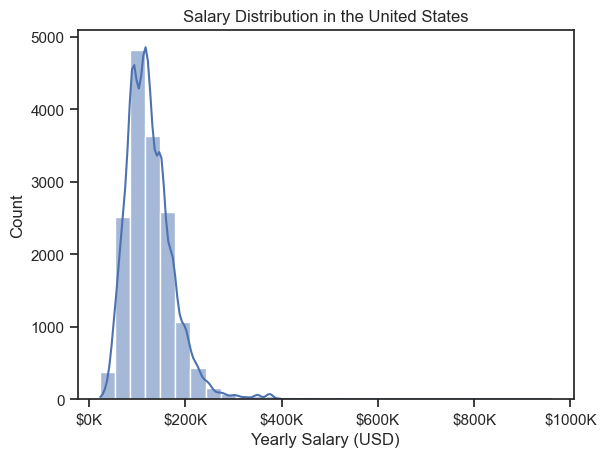

In [45]:
df_US = df[df['job_country'] == 'United States'].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

sns.histplot(data = df_US, x = 'salary_year_avg', bins = 30, kde = True)

plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Count')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

plt.show()